# 11. 한국어 감성분석 — 영어에서 한국어로

노트북 10에서 IMDB(영어 영화 리뷰)로 감성분석을 맛봤다. 이번엔 두 가지를 더 한다.

1. **IMDB 심화** — 리뷰 길이 분포를 보고, `maxlen`·`num_words`를 데이터에 맞게 정하고, **Bidirectional LSTM**으로 성능을 끌어올린다.
2. **한국어 NSMC** — 진짜 한국어 데이터(네이버 영화 리뷰 20만 건)로 **처음부터 끝까지** 감성분석 파이프라인을 만든다.

한국어는 영어처럼 준비된 데이터셋이 없다. **직접 형태소 분석하고, 단어 사전을 만들고, 인덱싱**해야 한다.
노트북 09(KoNLPy)와 10(임베딩)에서 배운 걸 전부 합치는 실전 편이다.

> `konlpy` 라이브러리를 쓴다. LSTM 학습은 **GPU 런타임**을 강력히 권장한다 (CPU는 매우 느리다).


## 1부. IMDB 심화 — 데이터를 보고 결정하기

노트북 10에서는 `maxlen=200`을 그냥 정했다. 이번엔 **데이터를 먼저 본다** (시리즈 내내 반복된 교훈).

### 1-1. 리뷰 길이 분포 확인

리뷰마다 길이가 다르다. **대부분 몇 단어쯤인지** 봐야 `maxlen`을 제대로 정할 수 있다.
너무 짧으면 정보가 잘리고, 너무 길면 대부분이 패딩(0)으로 낭비된다.


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
전체 단어 종류: 88584


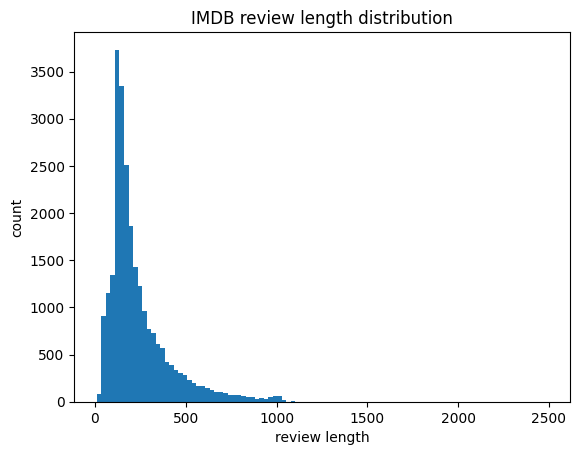

In [1]:
from tensorflow.keras.datasets import imdb
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = imdb.load_data()
print("전체 단어 종류:", len(imdb.get_word_index()))

# 리뷰 길이 분포
plt.hist([len(sent) for sent in x_train], bins=100)
plt.xlabel('review length'); plt.ylabel('count')
plt.title('IMDB review length distribution')
plt.show()


### 1-2. 자주 쓰는 단어만 (num_words)

88,584개 단어를 다 쓸 필요는 없다. 드물게 나오는 단어는 학습에 방해만 된다.
`num_words=5000` : **가장 자주 나오는 상위 5000개**만 쓴다. 나머지는 `<unk>`로 처리된다.


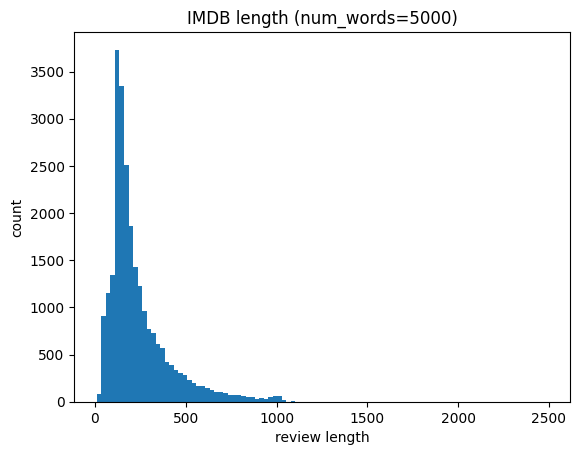

길이 중앙값: 178 | 평균: 238


In [2]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

# 길이 분포를 보고 maxlen 결정
plt.hist([len(sent) for sent in x_train], bins=100)
plt.xlabel('review length'); plt.ylabel('count')
plt.title('IMDB length (num_words=5000)')
plt.show()
print("길이 중앙값:", int(np.median([len(s) for s in x_train])),
      "| 평균:", int(np.mean([len(s) for s in x_train])))


### 1-3. 패딩과 Bidirectional LSTM

- `maxlen=300` : 길이 분포를 보고 정했다 (대부분을 담되 과하지 않게).
- 모델은 노트북 10의 LSTM을 **Bidirectional**로 강화한다 (노트북 08).
  리뷰를 **앞→뒤 + 뒤→앞** 양방향으로 읽어 문맥을 더 잘 잡는다.

```
Input(300) → Embedding(5000, 128) → Bidirectional(LSTM(32)) → Dense(1, sigmoid)
```
- `Embedding(5000, 128)` : 5000단어를 128차원 벡터로 (노트북 10보다 큰 임베딩).


In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense

x_train_pad = pad_sequences(x_train, maxlen=300)
x_test_pad = pad_sequences(x_test, maxlen=300)
print("패딩 후:", x_train_pad.shape)

model = Sequential()
model.add(Input(shape=(300,)))
model.add(Embedding(5000, 128))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_pad, y_train,
                 validation_data=(x_test_pad, y_test),
                 epochs=3, batch_size=128)


패딩 후: (25000, 300)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 681,281 (2.60 MB)

 Trainable params: 681,281 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7891 - loss: 0.4456 - val_accuracy: 0.8452 - val_loss: 0.3876
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.8916 - loss: 0.2782 - val_accuracy: 0.8752 - val_loss: 0.2993
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9159 - loss: 0.2224 - val_accuracy: 0.8596 - val_loss: 0.3259


## 2부. 한국어 감성분석 — NSMC (네이버 영화 리뷰)

IMDB는 영어라 Keras가 **이미 숫자로** 만들어 줬다. 한국어는 그런 게 없다.
**원문 텍스트부터 시작해서 직접 다 만들어야** 한다. 실전 NLP의 진짜 모습이다.

**NSMC**(Naver Sentiment Movie Corpus): 네이버 영화 리뷰 20만 건(학습 15만 / 테스트 5만).
각 리뷰에 긍정(1)/부정(0) 라벨이 달려 있다.

전체 파이프라인:
```
원문 리뷰  →  Okt 형태소 분석  →  단어 사전 만들기  →  숫자로 인덱싱  →  패딩  →  Bi-LSTM
 (한국어)      (명사·형용사만)      (상위 5000개)                                     (감성분석)
```

### 2-1. 데이터 다운로드

`urllib`로 NSMC 원본 파일을 직접 내려받는다. 탭으로 구분된 텍스트라 `pandas`로 읽는다.


In [4]:
import urllib.request
import pandas as pd

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", "ratings_train.txt")
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", "ratings_test.txt")

train_data = pd.read_table("ratings_train.txt")
test_data = pd.read_table("ratings_test.txt")
print("학습:", len(train_data), "| 테스트:", len(test_data))
train_data.head()


학습: 150000 | 테스트: 50000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [5]:
!pip install konlpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 40.2 MB/s eta 0:00:00


### 2-2. 단어 사전 만들기 — 형태소 분석 후 빈도 세기

한국어는 조사·어미가 붙으니 **형태소로 쪼개야** 한다 (노트북 09).
Okt로 분석해서 **명사·형용사만** 골라 빈도를 센다 (감성에 중요한 품사).

> ⚠️ 15만 건 형태소 분석이라 **수 분~십수 분** 걸린다. GPU와 무관하게 CPU 작업이라 오래 걸린다.
> 결측치(빈 리뷰)는 `nan`이라 `try/except`로 건너뛴다.


In [6]:
from konlpy.tag import Okt

okt = Okt()
wrdcnt = {}
for i, sent in enumerate(train_data.document):
    if i % 20000 == 0:
        print(f"진행: {i}/{len(train_data)}")
    try:
        for w, p in okt.pos(sent):
            if p in ('Noun', 'Adjective'):     # 명사·형용사만
                wrdcnt[w] = wrdcnt.get(w, 0) + 1
    except:
        pass    # 빈 리뷰(nan) 건너뛰기

print("고유 단어 수:", len(wrdcnt))


진행: 0/150000
진행: 20000/150000
진행: 40000/150000
진행: 60000/150000
진행: 80000/150000
진행: 100000/150000
진행: 120000/150000
진행: 140000/150000
고유 단어 수: 58661


### 2-3. 사전을 파일로 저장 (pickle)

형태소 분석은 오래 걸렸다. 결과를 **파일로 저장**해두면 다시 안 돌려도 된다.
`pickle`은 파이썬 객체(여기선 딕셔너리)를 그대로 파일에 저장하는 도구다.

> 노트북 04의 `ModelCheckpoint`와 같은 발상 — **비싼 계산 결과를 디스크에 백업**한다.


In [7]:
import pickle

# 저장
with open("naver_word_dict.pickle", 'wb') as f:
    pickle.dump(wrdcnt, f)

# 다시 불러오기 (확인)
with open("naver_word_dict.pickle", 'rb') as f:
    wrdcnt = pickle.load(f)
print("저장·복원 완료. 단어 수:", len(wrdcnt))


저장·복원 완료. 단어 수: 58661


### 2-4. 상위 5000개 단어로 사전 구축

빈도순으로 정렬해서 **가장 많이 쓰인 상위 5000개**만 쓴다 (IMDB의 `num_words=5000`과 같은 발상).
드문 단어는 버린다.

- `wrd2idx` : 단어 → 번호 (1부터. 0은 패딩 자리)
- `idx2wrd` : 번호 → 단어 (복원용)


In [8]:
# 빈도순 정렬
wrdlst = sorted(wrdcnt.items(), key=lambda x: x[1], reverse=True)
print("최다 빈도 5개:", wrdlst[:5])
print("5000번째 단어:", wrdlst[5000])   # 이 빈도 미만은 버려짐

# 상위 5000개로 사전 만들기 (번호 1~5000)
wrd2idx = {w: i + 1 for i, (w, _) in enumerate(wrdlst[:5000])}
idx2wrd = {i + 1: w for i, (w, _) in enumerate(wrdlst[:5000])}
print("사전 크기:", len(wrd2idx))


최다 빈도 5개: [('영화', 50737), ('정말', 9645), ('진짜', 8343), ('이', 8001), ('점', 7930)]
5000번째 단어: ('피고', 22)
사전 크기: 5000


### 2-5. 리뷰를 숫자 시퀀스로 인덱싱

이제 각 리뷰를 **숫자 리스트로** 바꾼다:
1. Okt로 형태소 분석 → 명사·형용사만
2. 각 단어를 `wrd2idx`로 번호 변환 (사전에 없는 단어는 건너뜀)
3. 빈 리뷰(단어가 하나도 안 남은 것)는 제외

> 또 15만 건 형태소 분석이라 시간이 걸린다. (사전 만들 때와 별개로 한 번 더 도는 것)
> 원본은 리뷰마다 `print`를 찍어 출력이 폭발했는데, 여기선 진행률만 표시한다.


In [9]:
def encode_reviews(documents, labels):
    xs, ys = [], []
    for i, (sent, lbl) in enumerate(zip(documents, labels)):
        if i % 20000 == 0:
            print(f"진행: {i}/{len(documents)}")
        try:
            tmp = [wrd2idx[w] for w, p in okt.pos(sent)
                   if p in ('Noun', 'Adjective') and w in wrd2idx]
        except:
            continue        # 빈 리뷰(nan)
        if tmp:             # 단어가 하나라도 남은 경우만
            xs.append(tmp)
            ys.append(lbl)
    return xs, ys

x_train, y_train = encode_reviews(train_data.document, train_data.label)
print("\n인덱싱된 학습 리뷰:", len(x_train))
print("예시:", x_train[0], "→", [idx2wrd[i] for i in x_train[0]])


진행: 0/150000
진행: 20000/150000
진행: 40000/150000
진행: 60000/150000
진행: 80000/150000
진행: 100000/150000
진행: 120000/150000
진행: 140000/150000

인덱싱된 학습 리뷰: 145063
예시: [273, 3, 4987, 420] → ['더빙', '진짜', '짜증나네요', '목소리']


### 2-6. 길이 분포 확인 후 패딩

한국어 리뷰도 길이를 보고 `maxlen`을 정한다 (1부에서 IMDB에 한 것과 동일).
리뷰가 짧아서(명사·형용사만 남겼으니) `maxlen=30`이면 충분하다.


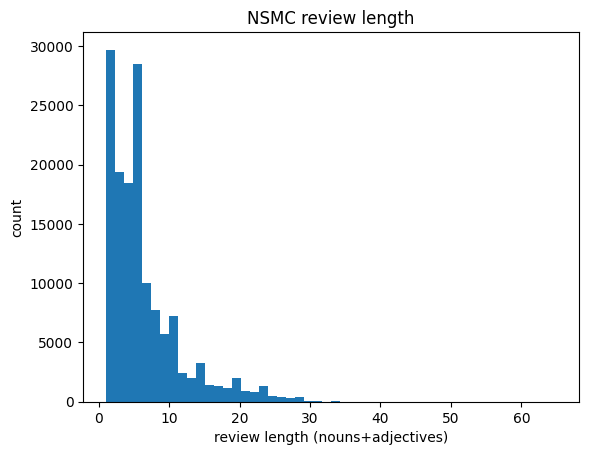

패딩 후: (145063, 30)


In [10]:
plt.hist([len(s) for s in x_train], bins=50)
plt.xlabel('review length (nouns+adjectives)')
plt.ylabel('count')
plt.title('NSMC review length')
plt.show()

x_train_pad = pad_sequences(x_train, maxlen=30)
y_train = np.array(y_train)
print("패딩 후:", x_train_pad.shape)


### 2-7. 테스트 데이터도 같은 방식으로

**중요**: 테스트 데이터는 **학습 때 만든 `wrd2idx`를 그대로** 써야 한다.
테스트용 사전을 새로 만들면 안 된다 (번호가 달라져 엉망이 된다).
사전에 없는 새 단어는 자연스럽게 무시된다.


In [11]:
x_test, y_test = encode_reviews(test_data.document, test_data.label)
x_test_pad = pad_sequences(x_test, maxlen=30)
y_test = np.array(y_test)
print("인덱싱된 테스트 리뷰:", len(x_test), "| 패딩:", x_test_pad.shape)


진행: 0/50000
진행: 20000/50000
진행: 40000/50000
인덱싱된 테스트 리뷰: 48351 | 패딩: (48351, 30)


### 2-8. 한국어 감성분석 모델 — Bi-LSTM

드디어 모델이다. 1부의 IMDB 모델과 **같은 구조**다. 언어만 바뀌었을 뿐, 뼈대는 동일하다.

```
Input(30) → Embedding(5001, 128) → Bidirectional(LSTM(32)) → Dense(1, sigmoid)
```
- `Embedding(5001, ...)` : 단어 5000개 + 패딩(0) = 5001.
- 앞의 모든 전처리가 있었기에, 모델 자체는 IMDB와 똑같이 간단하다.
  **한국어 NLP의 어려움은 모델이 아니라 전처리에 있다** — 이게 이 노트북의 핵심 교훈이다.


In [12]:
model = Sequential()
model.add(Input(shape=(30,)))
model.add(Embedding(5001, 128))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_pad, y_train,
                 validation_data=(x_test_pad, y_test),
                 epochs=5, batch_size=128)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 128)        │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 681,409 (2.60 MB)

 Trainable params: 681,409 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8081 - loss: 0.4089 - val_accuracy: 0.8262 - val_loss: 0.3797
Epoch 2/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8392 - loss: 0.3549 - val_accuracy: 0.8281 - val_loss: 0.3728
Epoch 3/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8488 - loss: 0.3338 - val_accuracy: 0.8269 - val_loss: 0.3774
Epoch 4/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8569 - loss: 0.3176 - val_accuracy: 0.8275 - val_loss: 0.3841
Epoch 5/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8641 - loss: 0.3016 - val_accuracy: 0.8265 - val_loss: 0.4031


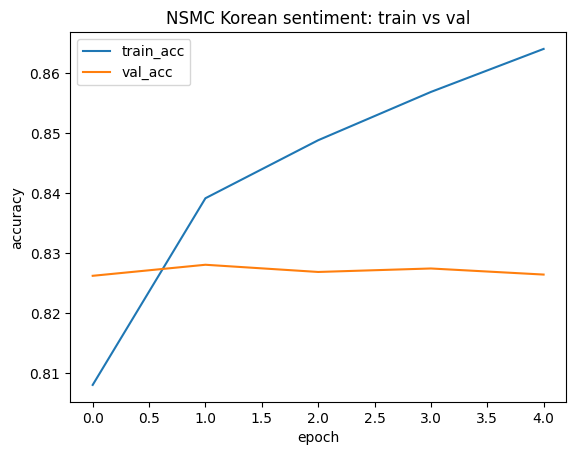

최고 검증 정확도: 0.8281


In [13]:
# 학습 곡선
plt.plot(hist.history['accuracy'], label='train_acc')
plt.plot(hist.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend()
plt.title('NSMC Korean sentiment: train vs val')
plt.show()

print("최고 검증 정확도:", round(max(hist.history['val_accuracy']), 4))


## 정리 — 한국어 감성분석

### 1부. IMDB 심화 (영어)

- **데이터를 먼저 봤다**: 리뷰 길이 중앙값 178 / 평균 238 → `maxlen=300`을 근거 있게 정했다.
  (노트북 10에서 `maxlen=200`을 그냥 정했던 것과 대비 — 시리즈 내내 반복된 "데이터를 먼저 보라".)
- **Bidirectional LSTM** (파라미터 681,281): 3에폭 검증 정확도 **0.8752**(에폭2 최고).
  에폭3엔 0.8596으로 떨어졌다 — **과적합 시작**.

### 2부. 한국어 NSMC — 전처리가 전부다 ★

원문 리뷰 20만 건으로 **처음부터 끝까지** 파이프라인을 만들었다:

| 단계 | 결과 |
|---|---|
| 다운로드 | 학습 150,000 / 테스트 50,000 |
| Okt 형태소 분석 (명사·형용사) | 고유 단어 **58,661개** |
| 상위 5000개로 사전 | 5000번째 단어 '피고'(22회) — 이 미만은 버림 |
| 인덱싱 | 학습 145,063 / 테스트 48,351 (빈 리뷰 제외) |
| 예시 | `[273,3,4987,420]` → `['더빙','진짜','짜증나네요','목소리']` |
| Bi-LSTM (5에폭) | 검증 정확도 **0.8281** |

**학습 곡선(셀 위)이 이 노트북의 핵심 장면이다:**
train_acc는 0.808 → 0.864로 꾸준히 오르는데, **val_acc는 에폭1 이후 0.827에서 평평하게 멈췄다.**
두 곡선이 벌어지는 이 그림 — **노트북 01에서 처음 본 과적합**의 한국어 버전이다.
5에폭 이상은 학습 데이터만 더 외울 뿐, 실전 성능은 안 오른다. (여기에 `EarlyStopping`을 붙이면 딱이다.)

#### 왜 한국어가 영어(0.85)보다 낮을까 (0.83)

- 한국어는 어순이 자유롭고 조사·어미 변형이 많아 본래 어렵다.
- **명사·형용사만** 남겨서 "안/못" 같은 부정 표현(부사·동사)이 빠졌다 — 감성분석엔 뼈아픈 손실.
- 상위 5000단어만 써서 드문 표현이 `<unk>`로 사라졌다.

> **가장 큰 교훈: 한국어 NLP의 어려움은 모델이 아니라 전처리에 있다.**
> 1부와 2부의 **모델은 글자 한 자 다르지 않다** (Embedding + Bi-LSTM + Dense).
> 영어는 Keras가 전처리를 다 해줘서 셀 3개면 끝났지만,
> 한국어는 다운로드·형태소 분석·사전 구축·인덱싱·캐싱까지 **전처리가 노트북의 대부분**이었다.
> 실전 한국어 NLP를 한다는 건 이 전처리 파이프라인을 다룰 줄 안다는 뜻이다.

---

| 개념 | 핵심 |
|---|---|
| **데이터 먼저 보기** | 길이 분포로 `maxlen` 결정 (IMDB 300, NSMC 30) |
| **num_words / 상위 N** | 자주 쓰는 단어만. 드문 단어는 `<unk>`로 |
| **한국어 파이프라인** | 형태소 분석 → 사전 구축 → 인덱싱 → 패딩 (직접 다 함) |
| **pickle / npy 캐싱** | 비싼 전처리 결과를 파일로 백업 (04의 ModelCheckpoint와 같은 발상) |
| **테스트=학습 사전** | 테스트는 학습 때 만든 `wrd2idx`를 그대로 써야 함 |
| **Bidirectional LSTM** | 양방향으로 읽어 문맥 강화 (모델은 영/한 동일) |

---

## Day6를 마치며 — 실전 NLP의 모습

이 노트북은 지금까지 배운 걸 **하나의 실전 과제**로 묶었다:

```
09 형태소 분석  +  10 임베딩  +  08 LSTM  +  01 과적합 관찰
        ↓
  한국어 영화 리뷰 20만 건 감성분석 (검증 0.83)
```

깔끔한 예제(IMDB)와 지저분한 실전(NSMC)의 차이를 직접 겪은 것이 이 노트북의 값어치다.
다음 단계는 **KoBERT·KoGPT** 같은 사전학습 한국어 모델 — 하지만 그것들도 결국
여기서 만든 "텍스트 → 토큰 → 벡터 → 모델"의 흐름 위에 서 있다.

수고하셨습니다. 🎉